# RANDOM - DATA

In [2]:
# ─────────────────────────────────────────────
# LIBRAIRIES
# ─────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
import polars as pl
import polars.selectors as cs
from pathlib import Path


# ─────────────────────────────────────────────
# CHARGEMENT & TRI
# ─────────────────────────────────────────────

mu    = 180
theta = 90

root  = Path("/home/nicolas/Documents/Workspace/nucleo/outputs/2026-03-31__PSMN")
paths = [str(p) for p in root.rglob("*.parquet")]

df_random = (
    pl.scan_parquet(paths)
    .filter(
        (pl.col("landscape") == "random") &
        (pl.col("mu")        == mu)       &
        (pl.col("theta")     == theta)
    )
    .select(cs.numeric() | cs.boolean() | cs.string() | pl.col("results") | pl.col("results_mean"))
    .collect()
    .sort(["landscape", "bpmin", "l"])
)


# ─────────────────────────────────────────────
# EXTRACTION DES VALEURS
# ─────────────────────────────────────────────

landscape    = df_random["landscape"].to_list()[0]
mu           = df_random["mu"].to_numpy()[0]
th           = df_random["theta"].to_numpy()[0]
s            = df_random["s"].to_numpy()[0]
Lmin         = df_random["Lmin"].to_numpy()[0]
Lmax         = df_random["Lmax"].to_numpy()[0]
bps          = df_random["bps"].to_numpy()[0]
tmax         = df_random["tmax"].to_numpy()[0]
dt           = df_random["dt"].to_numpy()[0]

l            = df_random["l"].to_numpy()
bpmin        = df_random["bpmin"].to_numpy()
results      = df_random["results"].to_numpy()
results_mean = df_random["results_mean"].to_numpy()
v_mean       = df_random["v_mean"].to_numpy()
vi_med       = df_random["vi_med"].to_numpy()
wf           = df_random["wf"].to_numpy()

l_values     = np.unique(l)
bpmin_values = np.unique(bpmin)

d            = 1 / (s + l)
v_th         = mu * d * l
ratio        = v_mean / v_th
c            = (150 + l) / (35 + l)
v_mean_bp    = v_mean * c

chromatin    = np.arange(Lmin, Lmax, bps)
time         = np.arange(0, tmax, dt)

# Colormap partagée (bpmin)
cmap = plt.cm.plasma
norm = plt.Normalize(vmin=bpmin_values.min(), vmax=bpmin_values.max())

# RANDOM - FIGURES

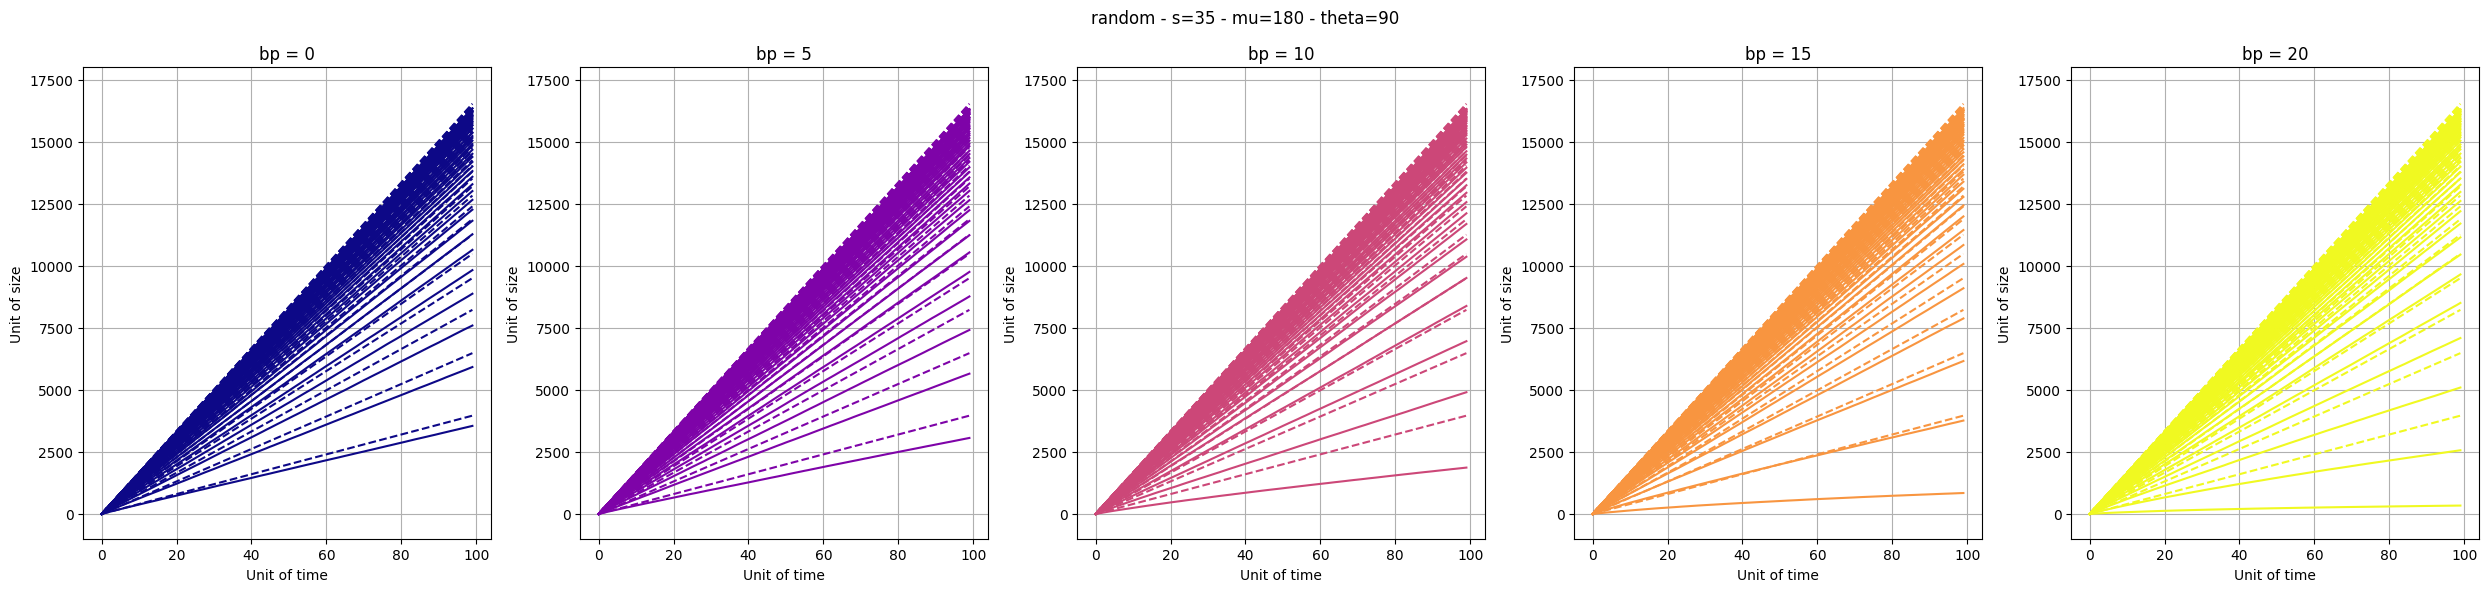

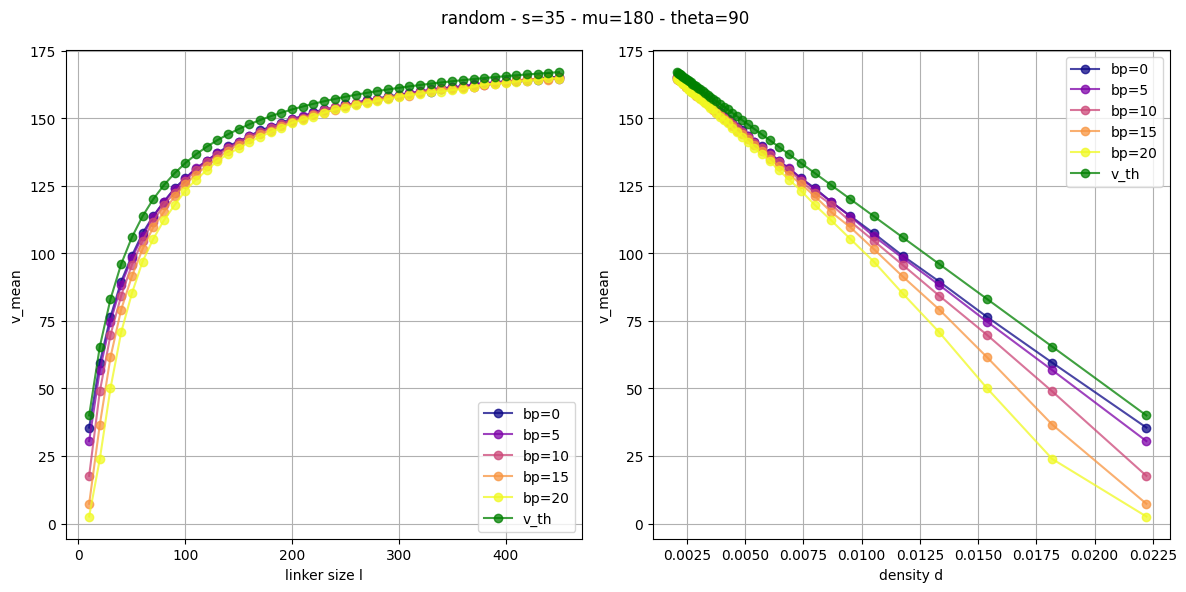

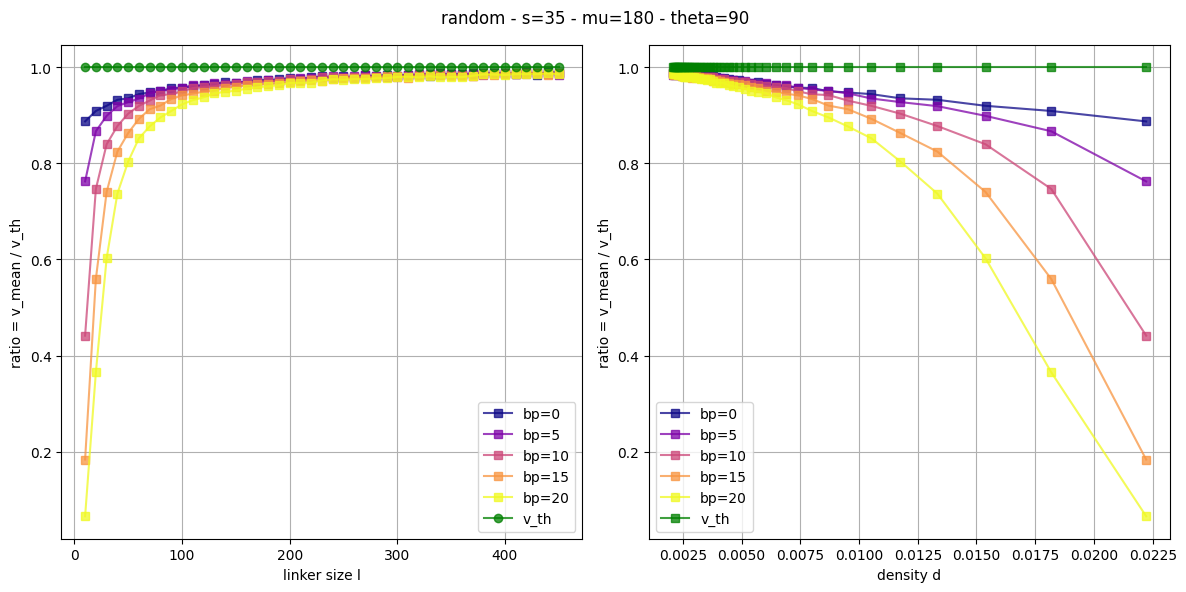

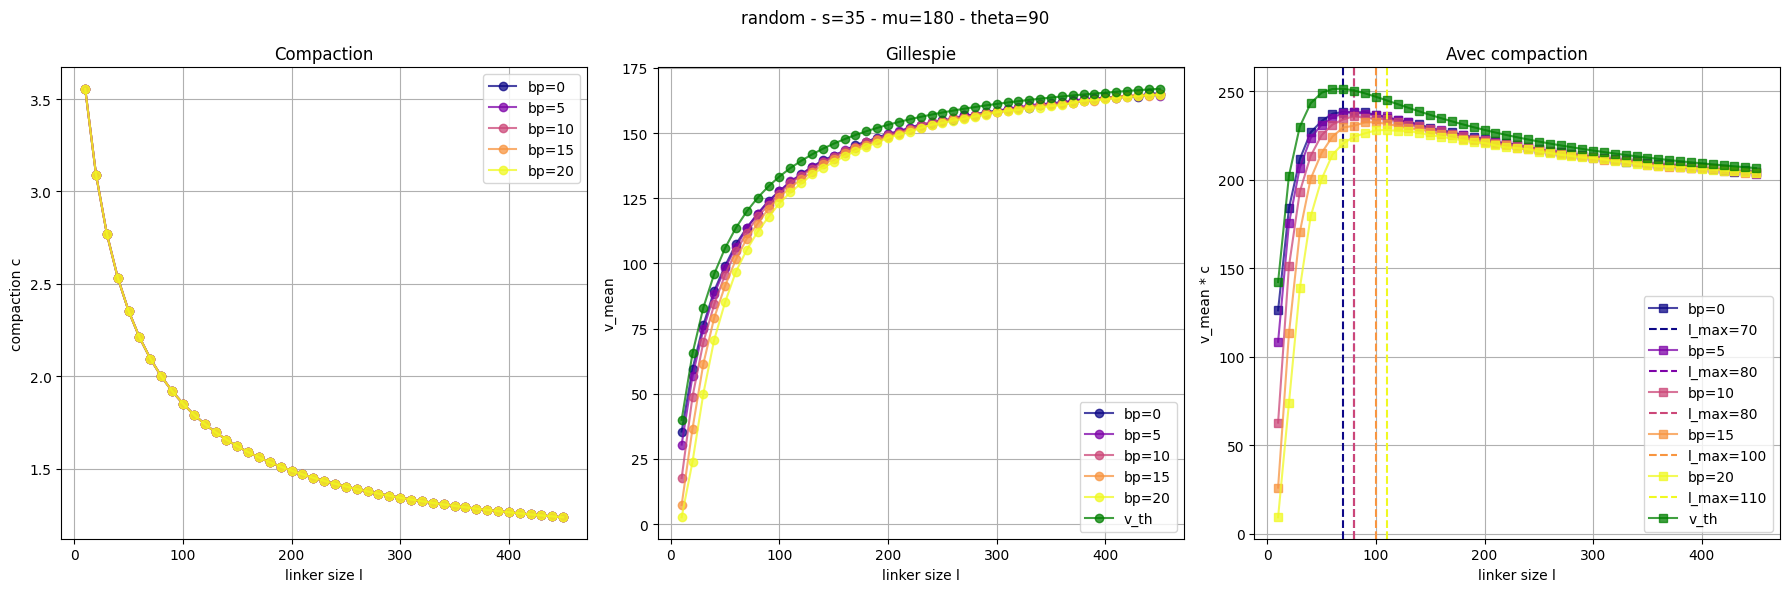

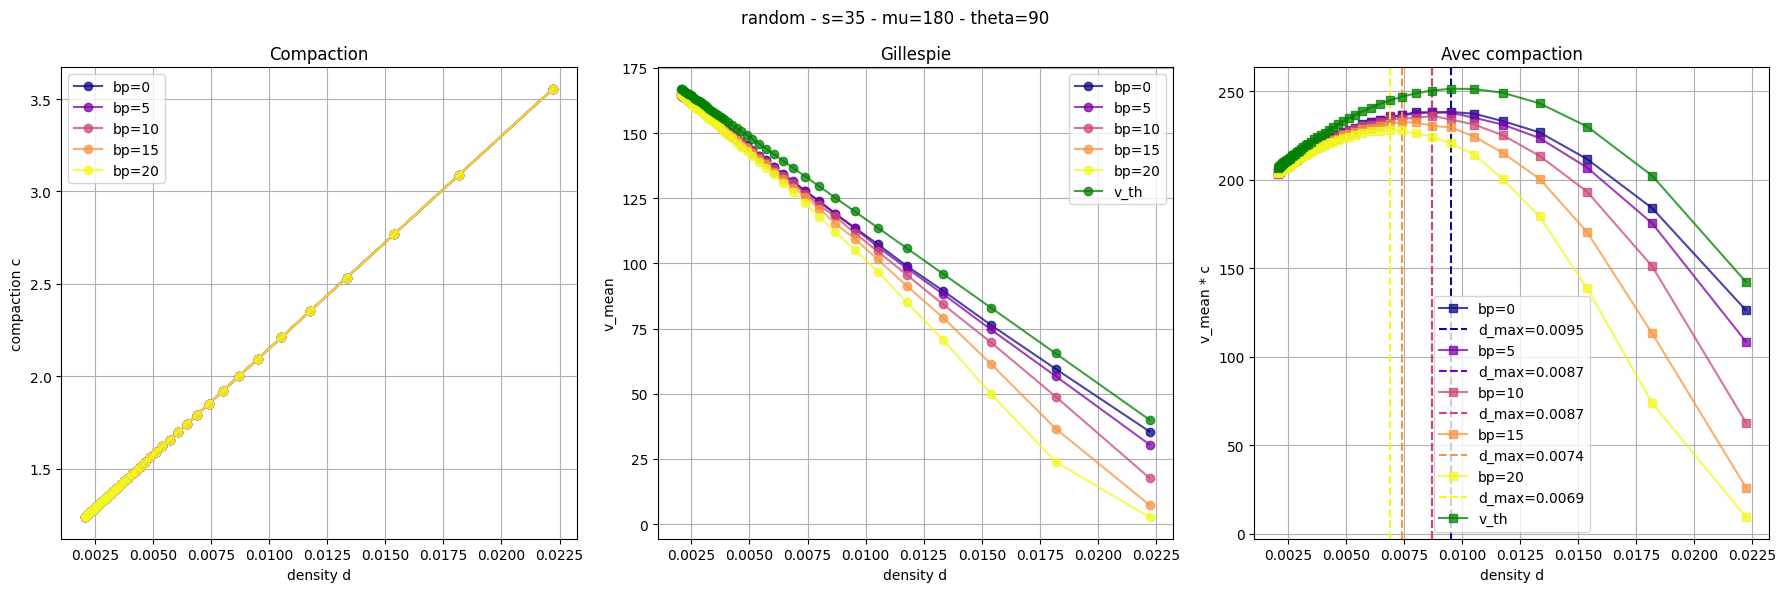

In [3]:
# ─────────────────────────────────────────────
# FIGURE 1 — Trajectoires
# ─────────────────────────────────────────────

nc  = len(bpmin_values)
fig, axs = plt.subplots(1, nc, figsize=(5 * nc, 6))
plt.suptitle(f"{landscape} - s={s} - mu={mu} - theta={th}")

if nc == 1:
    axs = [axs]

for ax, bp in zip(axs, bpmin_values):
    df_bp        = df_random.filter(pl.col("bpmin") == bp)
    results_bp   = df_bp["results_mean"].to_numpy()
    wf_bp        = df_bp["wf"].to_numpy()
    l_bp         = df_bp["l"].to_numpy()
    d_bp         = 1 / (s + l_bp)
    v_th_bp      = mu * d_bp * l_bp

    for res, l_val, d_val, v_th_val, wf_val in zip(results_bp, l_bp, d_bp, v_th_bp, wf_bp):
        color = cmap(norm(bp))
        ax.plot(time, res,            color=color, ls="-",  label=f"l={l_val} - d={d_val:.3f} model - wf={wf_val}")
        ax.plot(time, time * v_th_val, color=color, ls="--", label=f"l={l_val} - d={d_val:.3f} theo  - wf={wf_val}")

    ax.set_title(f"bp = {bp}")
    ax.set_xlabel("Unit of time")
    ax.set_ylabel("Unit of size")
    ax.set_ylim([-1_000, 18_000])
    ax.grid(True, which="both")

plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────
# FIGURE 2 — v_mean vs l et vs d
# ─────────────────────────────────────────────

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
plt.suptitle(f"{landscape} - s={s} - mu={mu} - theta={th}")

for bp in bpmin_values:
    color    = cmap(norm(bp))
    df_bp    = df_random.filter(pl.col("bpmin") == bp)
    l_bp     = df_bp["l"].to_numpy()
    d_bp     = 1 / (s + l_bp)
    v_mean_bp_plot = df_bp["v_mean"].to_numpy()

    axs[0].plot(l_bp, v_mean_bp_plot, color=color, marker="o", alpha=0.75, label=f"bp={bp}")
    axs[1].plot(d_bp, v_mean_bp_plot, color=color, marker="o", alpha=0.75, label=f"bp={bp}")

# Théorique (dernière valeur de bp suffit, v_th ne dépend pas de bp)
axs[0].plot(l_bp, mu * d_bp * l_bp, color="g", marker="o", alpha=0.75, label="v_th")
axs[1].plot(d_bp, mu * d_bp * l_bp, color="g", marker="o", alpha=0.75, label="v_th")

for ax, xlabel in zip(axs, ["linker size l", "density d"]):
    ax.set_xlabel(xlabel)
    ax.set_ylabel("v_mean")
    ax.grid(True, which="both")
    ax.legend()

plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────
# FIGURE 3 — Ratio v_mean / v_th vs l et vs d
# ─────────────────────────────────────────────

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
plt.suptitle(f"{landscape} - s={s} - mu={mu} - theta={th}")

for bp in bpmin_values:
    color    = cmap(norm(bp))
    df_bp    = df_random.filter(pl.col("bpmin") == bp)
    l_bp     = df_bp["l"].to_numpy()
    d_bp     = 1 / (s + l_bp)
    v_mean_plot = df_bp["v_mean"].to_numpy()
    v_th_plot   = mu * d_bp * l_bp
    ratio_plot  = v_mean_plot / v_th_plot

    axs[0].plot(l_bp, ratio_plot, color=color, marker="s", alpha=0.75, label=f"bp={bp}")
    axs[1].plot(d_bp, ratio_plot, color=color, marker="s", alpha=0.75, label=f"bp={bp}")

axs[0].plot(l_bp, np.ones_like(l_bp), color="g", marker="o", alpha=0.75, label="v_th")
axs[1].plot(d_bp, np.ones_like(d_bp), color="g", marker="s", alpha=0.75, label="v_th")

for ax, xlabel in zip(axs, ["linker size l", "density d"]):
    ax.set_xlabel(xlabel)
    ax.set_ylabel("ratio = v_mean / v_th")
    ax.grid(True, which="both")
    ax.legend()

plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────
# FIGURE 4 — Compaction + v_mean + v_mean*c  vs l
# ─────────────────────────────────────────────

fig, axs = plt.subplots(1, 3, figsize=(18, 6))
plt.suptitle(f"{landscape} - s={s} - mu={mu} - theta={th}")

for bp in bpmin_values:
    color    = cmap(norm(bp))
    df_bp    = df_random.filter(pl.col("bpmin") == bp)
    l_bp     = df_bp["l"].to_numpy()
    d_bp     = 1 / (s + l_bp)
    v_mean_plot  = df_bp["v_mean"].to_numpy()
    v_th_plot    = mu * d_bp * l_bp
    c_plot       = (150 + l_bp) / (35 + l_bp)
    v_mean_c     = v_mean_plot * c_plot
    i_max        = np.argmax(v_mean_c)

    axs[0].plot(l_bp, c_plot, color=color, marker="o", alpha=0.75, label=f"bp={bp}")
    axs[1].plot(l_bp, v_mean_plot, color=color, marker="o", alpha=0.75, label=f"bp={bp}")
    axs[2].plot(l_bp, v_mean_c,    color=color, marker="s", alpha=0.75, label=f"bp={bp}")
    axs[2].axvline(l_bp[i_max], color=color, ls="--", label=f"l_max={l_bp[i_max]}")

axs[1].plot(l_bp, v_th_plot,          color="g", marker="o", alpha=0.75, label="v_th")
axs[2].plot(l_bp, v_th_plot * c_plot, color="g", marker="s", alpha=0.75, label="v_th")

axs[0].set_xlabel("linker size l") ; axs[0].set_ylabel("compaction c") ; axs[0].set_title("Compaction")
axs[1].set_xlabel("linker size l") ; axs[1].set_ylabel("v_mean")        ; axs[1].set_title("Gillespie")
axs[2].set_xlabel("linker size l") ; axs[2].set_ylabel("v_mean * c")    ; axs[2].set_title("Avec compaction")

for ax in axs:
    ax.grid(True, which="both")
    ax.legend()

plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────
# FIGURE 5 — Compaction + v_mean + v_mean*c  vs d
# ─────────────────────────────────────────────

fig, axs = plt.subplots(1, 3, figsize=(18, 6))
plt.suptitle(f"{landscape} - s={s} - mu={mu} - theta={th}")

for bp in bpmin_values:
    color    = cmap(norm(bp))
    df_bp    = df_random.filter(pl.col("bpmin") == bp)
    l_bp     = df_bp["l"].to_numpy()
    d_bp     = 1 / (s + l_bp)
    v_mean_plot  = df_bp["v_mean"].to_numpy()
    v_th_plot    = mu * d_bp * l_bp
    c_plot       = (150 + l_bp) / (35 + l_bp)
    v_mean_c     = v_mean_plot * c_plot
    i_max        = np.argmax(v_mean_c)

    axs[0].plot(d_bp, c_plot, color=color, marker="o", alpha=0.75, label=f"bp={bp}")
    axs[1].plot(d_bp, v_mean_plot, color=color, marker="o", alpha=0.75, label=f"bp={bp}")
    axs[2].plot(d_bp, v_mean_c,    color=color, marker="s", alpha=0.75, label=f"bp={bp}")
    axs[2].axvline(d_bp[i_max], color=color, ls="--", label=f"d_max={d_bp[i_max]:.4f}")

axs[1].plot(d_bp, v_th_plot,          color="g", marker="o", alpha=0.75, label="v_th")
axs[2].plot(d_bp, v_th_plot * c_plot, color="g", marker="s", alpha=0.75, label="v_th")

axs[0].set_xlabel("density d") ; axs[0].set_ylabel("compaction c") ; axs[0].set_title("Compaction")
axs[1].set_xlabel("density d") ; axs[1].set_ylabel("v_mean")        ; axs[1].set_title("Gillespie")
axs[2].set_xlabel("density d") ; axs[2].set_ylabel("v_mean * c")    ; axs[2].set_title("Avec compaction")

for ax in axs:
    ax.grid(True, which="both")
    ax.legend()

plt.tight_layout()
plt.show()

# PERIODIC - DATA

In [4]:
# ─────────────────────────────────────────────
# LIBRAIRIES
# ─────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
import polars as pl
import polars.selectors as cs
from pathlib import Path


# ─────────────────────────────────────────────
# CHARGEMENT & TRI
# ─────────────────────────────────────────────

mu    = 180
theta = 90

root  = Path("/home/nicolas/Documents/Workspace/nucleo/outputs/2026-03-31__PSMN")
paths = [str(p) for p in root.rglob("*.parquet")]

df_periodic = (
    pl.scan_parquet(paths)
    .filter(
        (pl.col("landscape") == "periodic") &
        (pl.col("mu")        == mu)         &
        (pl.col("theta")     == theta)
    )
    .select(cs.numeric() | cs.boolean() | cs.string() | pl.col("results_mean") | pl.col("alpha_mean_a"))
    .collect()
    .sort(["landscape", "bpmin", "l", "alphad"], descending=[False, False, False, False])
)


# ─────────────────────────────────────────────
# EXTRACTION DES VALEURS
# ─────────────────────────────────────────────

landscape = df_periodic["landscape"].to_list()[0]
mu        = df_periodic["mu"].to_numpy()[0]
th        = df_periodic["theta"].to_numpy()[0]
Lmin      = df_periodic["Lmin"].to_numpy()[0]
Lmax      = df_periodic["Lmax"].to_numpy()[0]
bps       = df_periodic["bps"].to_numpy()[0]
tmax      = df_periodic["tmax"].to_numpy()[0]
dt        = df_periodic["dt"].to_numpy()[0]

s         = df_periodic["s"].to_numpy()
l         = df_periodic["l"].to_numpy()
alphad    = df_periodic["alphad"].to_numpy()

s_values  = np.unique(s)
l_values  = np.unique(l)
alphads   = np.unique(alphad)

chromatin = np.arange(Lmin, Lmax, bps)
time      = np.arange(0, tmax, dt)

# Colormap partagée (alphad)
cmap_viridis = plt.cm.viridis
cmap_jet     = plt.cm.jet
norm_alphad  = plt.Normalize(vmin=alphads.min(), vmax=alphads.max())
norm_l       = plt.Normalize(vmin=l_values.min(), vmax=l_values.max())

# Subset l restreint (figures vs alphad)
df_subset = df_periodic.filter((pl.col("l") >= 5) & (pl.col("l") <= 150))

# PERIODIC - FIGURES

alphad = 0.00 - alpha_value = 0.22 - [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
alphad = 0.10 - alpha_value = 0.30 - [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.09690000116825104, 0.09690000116825104, 0.09690000116825104, 0.09690000116825104, 0.09690000116825104, 0.09690000116825104, 0.09690000116825104, 0.09690000116825104, 0.09690000116825104, 0.09690000116825104, 0.09690000116825104, 0.09690000116825104, 0.09690000116825104, 0.09690000116825104, 0.09690000116825104, 0.09690000116825104, 0.09690000116825104, 0.096900001168251

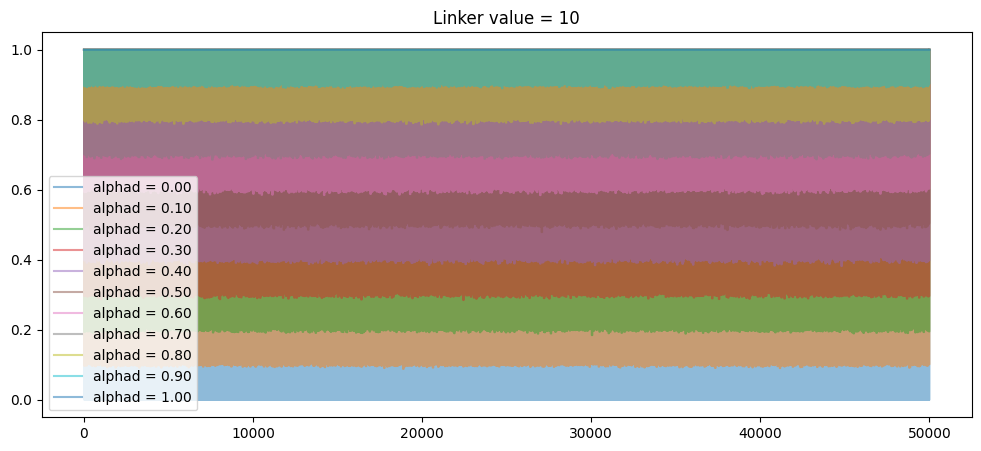

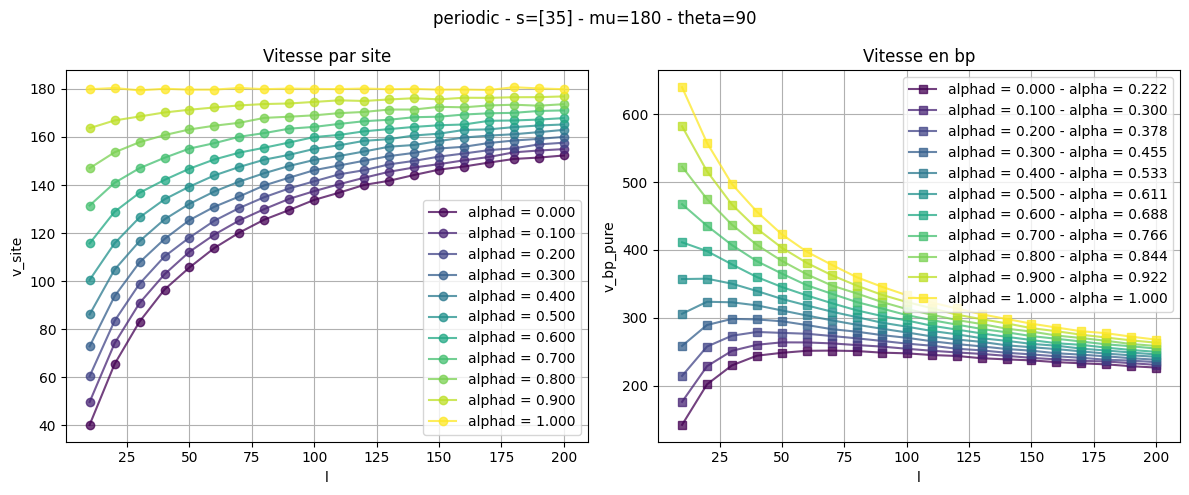

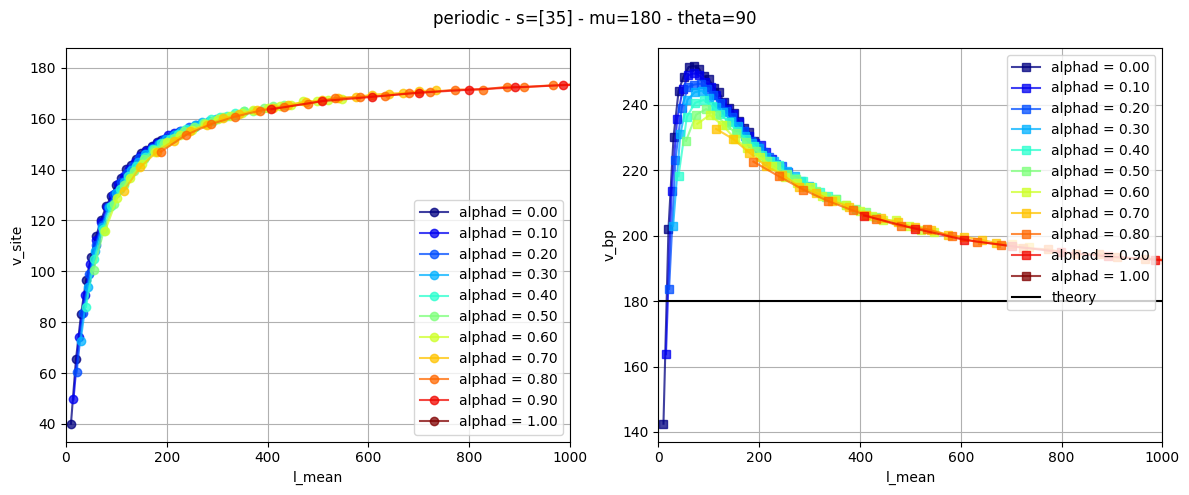

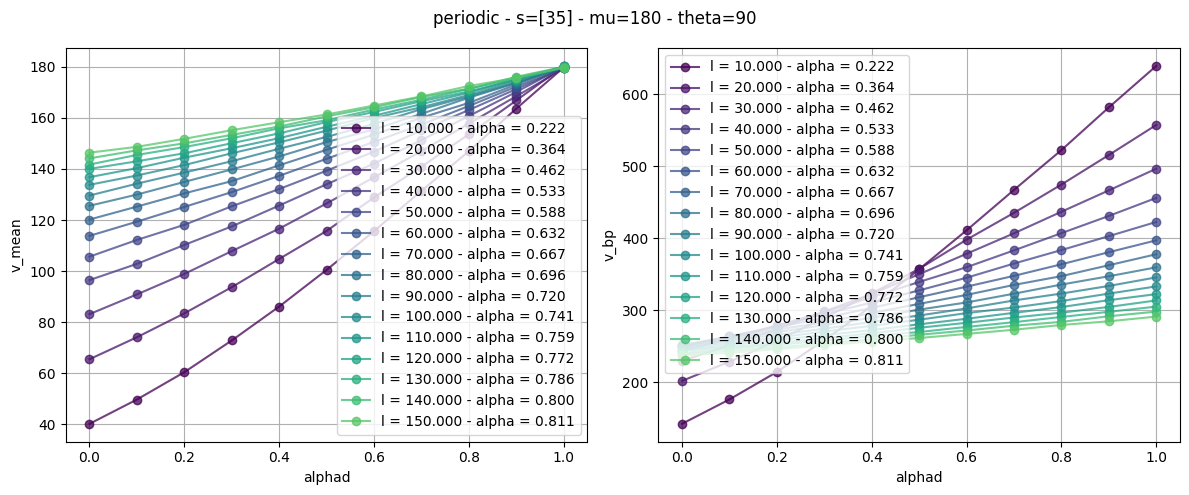

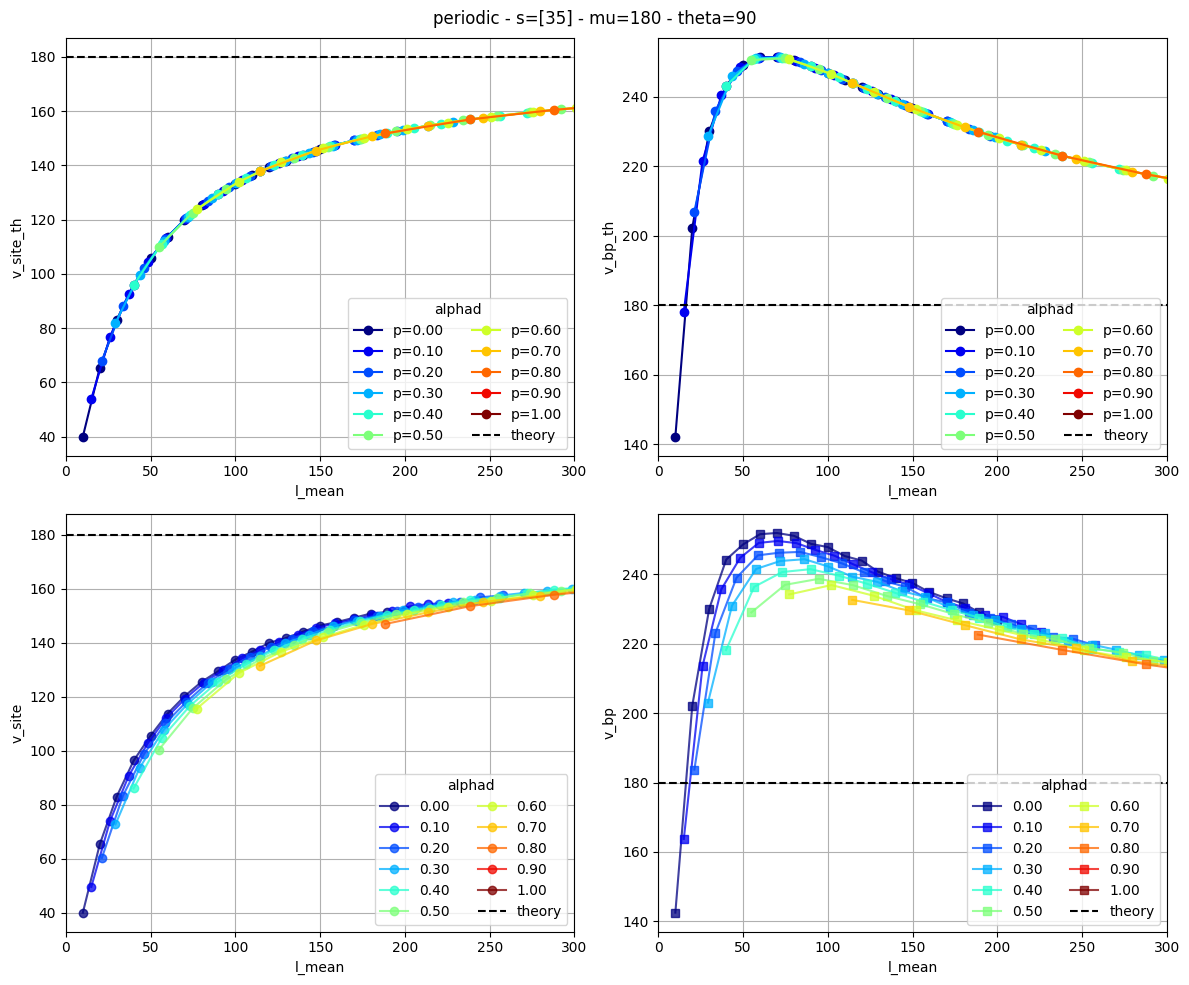

In [5]:
# ─────────────────────────────────────────────
# FIGURE 1 — Destruction des obstacles
# ─────────────────────────────────────────────

l_value = 10
df_sub  = df_periodic.filter(pl.col("l") == l_value)

plt.figure(figsize=(12, 5))

for row in df_sub.iter_rows(named=True):
    alpha_mean_a = row["alpha_mean_a"]
    alphad_val   = row["alphad"]
    alpha_value  = np.mean(alpha_mean_a)
    plt.plot(alpha_mean_a, alpha=0.50, label=f"alphad = {alphad_val:.2f}")
    print(f"alphad = {alphad_val:.2f} - alpha_value = {alpha_value:.2f} - {alpha_mean_a[0:100]}")

plt.title(f"Linker value = {l_value}")
plt.legend()
plt.show()


# ─────────────────────────────────────────────
# FIGURE 2 — v_site et v_bp vs l
# ─────────────────────────────────────────────

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
plt.suptitle(f"{landscape} - s={s_values} - mu={mu} - theta={th}")

for group in df_periodic.partition_by("alphad", as_dict=False):
    alphad_val   = group["alphad"][0]
    l_bp         = group["l"].to_numpy()
    v_site       = group["v_mean"].to_numpy()
    alpha_mean_a = group["alpha_mean_a"].to_numpy()[0]
    alpha_value  = np.mean(alpha_mean_a)
    c            = (150 + l_bp) / (35 + l_bp)
    color        = cmap_viridis(norm_alphad(alphad_val))

    axs[0].plot(l_bp, v_site,      color=color, marker="o", ls="-", alpha=0.75, label=f"alphad = {alphad_val:.3f}")
    axs[1].plot(l_bp, v_site * c,  color=color, marker="s",          alpha=0.75, label=f"alphad = {alphad_val:.3f} - alpha = {alpha_value:.3f}")

axs[0].set_xlabel("l") ; axs[0].set_ylabel("v_site")    ; axs[0].set_title("Vitesse par site")
axs[1].set_xlabel("l") ; axs[1].set_ylabel("v_bp_pure") ; axs[1].set_title("Vitesse en bp")

for ax in axs:
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────
# FIGURE 3 — v_site et v_bp vs l_mean
# ─────────────────────────────────────────────

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
plt.suptitle(f"{landscape} - s={s_values} - mu={mu} - theta={th}")

for group in df_periodic.partition_by("alphad", as_dict=False):
    alphad_val = group["alphad"][0]
    l_mean     = group["l_mean"].to_numpy()
    v_site     = group["v_mean"].to_numpy()
    c          = (150 + l_mean) / (35 + l_mean)
    color      = cmap_jet(norm_alphad(alphad_val))

    axs[0].plot(l_mean, v_site,      color=color, marker="o", ls="-", alpha=0.75, label=f"alphad = {alphad_val:.2f}")
    axs[1].plot(l_mean, v_site * c,  color=color, marker="s", ls="-", alpha=0.75, label=f"alphad = {alphad_val:.2f}")

axs[1].axhline(y=180, c="k", label="theory")

for ax in axs:
    ax.set_xlim([0, 1_000])
    ax.grid(True)
    ax.legend()

axs[0].set_xlabel("l_mean") ; axs[0].set_ylabel("v_site")
axs[1].set_xlabel("l_mean") ; axs[1].set_ylabel("v_bp")

plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────
# FIGURE 4 — v_site et v_bp vs alphad
# ─────────────────────────────────────────────

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
plt.suptitle(f"{landscape} - s={s_values} - mu={mu} - theta={th}")

for group in df_subset.partition_by("l", as_dict=False):
    l_val        = group["l"][0]
    alphad_arr   = group["alphad"].to_numpy()
    v_site       = group["v_mean"].to_numpy()
    alpha_mean_a = group["alpha_mean_a"].to_numpy()[0]
    alpha_value  = np.mean(alpha_mean_a[10_000:20_000])
    c            = (150 + l_val) / (35 + l_val)
    color        = cmap_viridis(norm_l(l_val))
    label        = f"l = {l_val:.3f} - alpha = {alpha_value:.3f}"

    axs[0].plot(alphad_arr, v_site,      color=color, marker="o", alpha=0.75, label=label)
    axs[1].plot(alphad_arr, v_site * c,  color=color, marker="o", alpha=0.75, label=label)

axs[0].set_xlabel("alphad") ; axs[0].set_ylabel("v_mean")
axs[1].set_xlabel("alphad") ; axs[1].set_ylabel("v_bp")

for ax in axs:
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────
# FIGURE 5 — Résultats principaux (2x2)
# ─────────────────────────────────────────────

xmax = 300

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
plt.suptitle(f"{landscape} - s={s_values} - mu={mu} - theta={th}")
(ax1, ax2), (ax3, ax4) = axes

# ax1 : v_mean_th_eff vs l_mean  (df_subset)
# ax2 : v_mean_th_eff * c vs l_mean  (df_subset)
for group in df_subset.partition_by("alphad", as_dict=False):
    alphad_val   = group["alphad"][0]
    l_mean       = group["l_mean"].to_numpy()
    v_th_eff     = group["v_mean_th_eff"].to_numpy()
    c            = (150 + l_mean) / (35 + l_mean)
    color        = cmap_jet(norm_alphad(alphad_val))
    ax1.plot(l_mean, v_th_eff,       color=color, marker="o", label=f"p={alphad_val:.2f}")
    ax2.plot(l_mean, v_th_eff * c,   color=color, marker="o", label=f"p={alphad_val:.2f}")

# ax3 : v_site vs l_mean  (df_sorted)
# ax4 : v_bp vs l_mean  (df_sorted)
for group in df_periodic.partition_by("alphad", as_dict=False):
    alphad_val = group["alphad"][0]
    l_mean     = group["l_mean"].to_numpy()
    v_site     = group["v_mean"].to_numpy()
    c          = (150 + l_mean) / (35 + l_mean)
    color      = cmap_jet(norm_alphad(alphad_val))
    ax3.plot(l_mean, v_site,      color=color, marker="o", ls="-", alpha=0.75, label=f"{alphad_val:.2f}")
    ax4.plot(l_mean, v_site * c,  color=color, marker="s", ls="-", alpha=0.75, label=f"{alphad_val:.2f}")

for ax, ylabel in zip([ax1, ax2, ax3, ax4], ["v_site_th", "v_bp_th", "v_site", "v_bp"]):
    ax.axhline(y=180, c="k", ls="--", label="theory")
    ax.set_xlim([0, xmax])
    ax.set_xlabel("l_mean")
    ax.set_ylabel(ylabel)
    ax.grid(True)
    ax.legend(title="alphad", ncols=2)

plt.tight_layout()
plt.show()

# RANDOM + PERIODIC : NEW METHOD

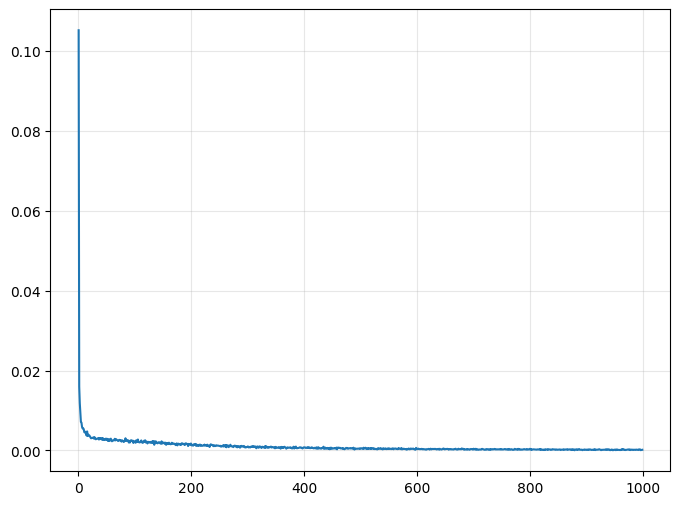

In [6]:
root = Path(
    "/home/nicolas/Documents/Workspace/nucleo/outputs/2026-03-31__PSMN/nucleo__compactionrandom_2/algorithm=one_step__fact=False__factmode=none__destroy=True__landscape=random__s=35__l=30__bpmin=20__mu=150__theta=20__alphad=0.00e+00__alphar=0.00e+00__kB=1.00e+00__kU=0.00e+00__nt=10000__"
)
df = pl.read_parquet(root)

x = df["vc_points"][0].to_numpy()
y = df["vc_distrib"][0].to_numpy()

plt.figure(figsize=(8,6))
plt.plot(x,y)
plt.grid(True, which="both", alpha=0.3)
# plt.loglog(True)
plt.show()

In [7]:
# ─────────────────────────────────────────────
# LIBRAIRIES
# ─────────────────────────────────────────────

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from pathlib import Path


# ─────────────────────────────────────────────
# PARAMETERS
# ─────────────────────────────────────────────

s_selected     = 35
mu_selected    = 180
theta_selected = 90
l_try     = 10

xlim_main = 500
xlim_sub  = 2_000

params_periodic = [0.0, 0.3, 0.6, 0.9]  # alphad
params_random   = [0, 10, 20]            # bpmin


# ─────────────────────────────────────────────
# READING FUNCTION
# ─────────────────────────────────────────────

def load_scalar_columns(paths, extra_cols=None):
    lf = pl.scan_parquet(paths)
    scalar_cols = [
        name for name, dtype in lf.schema.items()
        if isinstance(dtype, (
            pl.Int8, pl.Int16, pl.Int32, pl.Int64,
            pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64,
            pl.Float32, pl.Float64,
            pl.Boolean, pl.Utf8
        ))
    ]
    if extra_cols is not None:
        if isinstance(extra_cols, str):
            extra_cols = [extra_cols]
        scalar_cols = list(set(scalar_cols + extra_cols))
    return lf.select(scalar_cols).collect()


# ─────────────────────────────────────────────
# ROOT
# ─────────────────────────────────────────────

root  = Path("/home/nicolas/Documents/Workspace/nucleo/outputs/2026-03-31__PSMN")
paths = [str(p) for p in root.glob("*/**/*.parquet")] or [str(p) for p in root.glob("*/*.parquet")]


# ─────────────────────────────────────────────
# DATA FRAMES
# ─────────────────────────────────────────────

df_compaction = (
    load_scalar_columns(paths, extra_cols=None)
    .sort(["landscape", "bpmin", "l", "alphad"])
    .filter(
        (pl.col("s")     == s_selected)     &
        (pl.col("mu")    == mu_selected)    &
        (pl.col("theta") == theta_selected)
    )
)

df_periodic = (
    df_compaction
    .filter(pl.col("landscape") == "periodic")
    .with_columns(pl.col("alphad").round(3))
    .filter(pl.col("alphad").is_in(params_periodic))
)

df_random = (
    df_compaction
    .filter(pl.col("landscape") == "random")
    .with_columns(pl.col("bpmin").round(3))
    .filter(pl.col("bpmin").is_in(params_random))
)

/tmp/ipykernel_447752/982290859.py:35: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  name for name, dtype in lf.schema.items()


/tmp/ipykernel_447752/3309908817.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


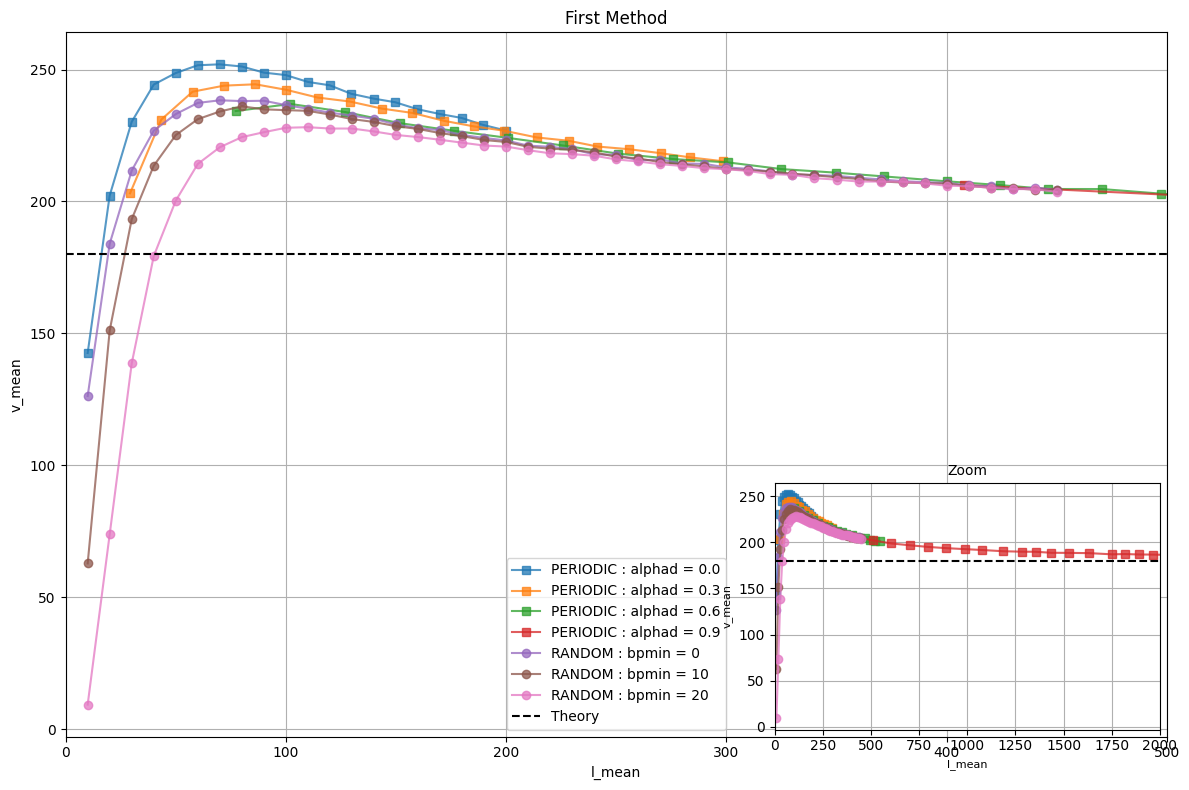

In [8]:
# ─────────────────────────────────────────────
# FIGURE - FIRST METHOD
# ─────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(12, 8))


# ── Main ──────────────────────────────────────

for group in df_periodic.partition_by("alphad", as_dict=False):
    alphad = group["alphad"][0]
    l_mean = group["l_mean"].to_numpy()
    v_bp   = group["v_mean"].to_numpy() * (150 + l_mean) / (s_selected + l_mean)
    ax.plot(l_mean, v_bp, marker="s", ls="-", alpha=0.75, label=f"PERIODIC : alphad = {alphad}")

for group in df_random.partition_by("bpmin", as_dict=False):
    bpmin  = group["bpmin"][0]
    l_mean = group["l"].to_numpy()
    v_bp   = group["v_mean"].to_numpy() * (150 + l_mean) / (s_selected + l_mean)
    ax.plot(l_mean, v_bp, marker="o", ls="-", alpha=0.75, label=f"RANDOM : bpmin = {bpmin}")

ax.axhline(mu_selected, c="k", ls="--", label="Theory")
ax.set_title("First Method")
ax.set_xlim([0, xlim_main])
ax.set_xlabel("l_mean")
ax.set_ylabel("v_mean")
ax.legend(loc="lower center")
ax.grid(True)


# ── Inset ─────────────────────────────────────

ax_inset = inset_axes(ax, width="35%", height="35%", loc="lower right")

for group in df_periodic.partition_by("alphad", as_dict=False):
    l_mean = group["l_mean"].to_numpy()
    v_bp   = group["v_mean"].to_numpy() * (150 + l_mean) / (s_selected + l_mean)
    ax_inset.plot(l_mean, v_bp, marker="s", ls="-", alpha=0.75)

for group in df_random.partition_by("bpmin", as_dict=False):
    l_mean = group["l"].to_numpy()
    v_bp   = group["v_mean"].to_numpy() * (150 + l_mean) / (s_selected + l_mean)
    ax_inset.plot(l_mean, v_bp, marker="o", ls="-", alpha=0.75)

ax_inset.axhline(mu_selected, c="k", ls="--")
ax_inset.set_xlim([0, xlim_sub])
ax_inset.set_ylim(ax.get_ylim())
ax_inset.set_xlabel("l_mean", fontsize=8)
ax_inset.set_ylabel("v_mean", fontsize=8)
ax_inset.set_title("Zoom", fontsize=10)
ax_inset.grid(True)


plt.tight_layout()
plt.show()

/tmp/ipykernel_447752/46287400.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


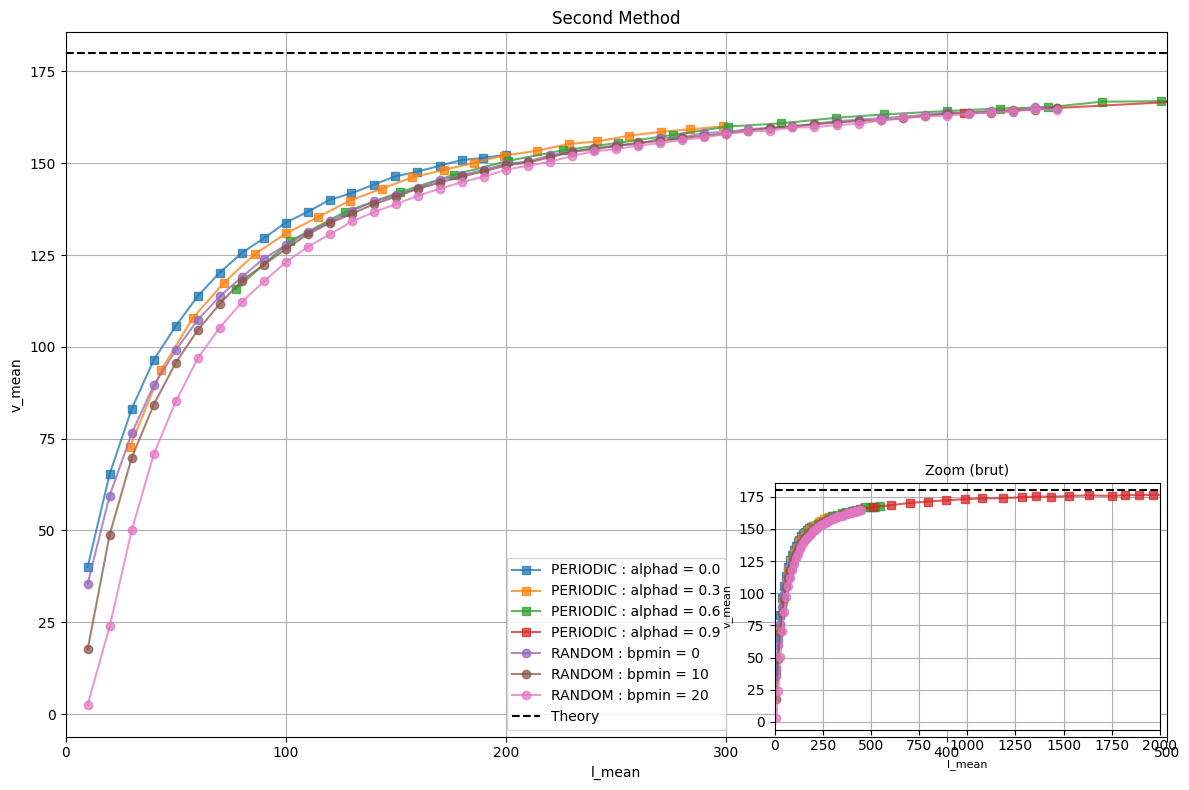

In [9]:
# ─────────────────────────────────────────────
# FIGURE - SECOND METHOD
# ─────────────────────────────────────────────

v_to_plot   = "v_mean"
theo_value  = mu_selected


fig, ax = plt.subplots(figsize=(12, 8))


# ── Main ──────────────────────────────────────

for group in df_periodic.partition_by("alphad", as_dict=False):
    alphad  = group["alphad"][0]
    l_mean  = group["l_mean"].to_numpy()
    vc      = group[v_to_plot].to_numpy()
    ax.plot(l_mean, vc, marker="s", ls="-", alpha=0.75, label=f"PERIODIC : alphad = {alphad}")

for group in df_random.partition_by("bpmin", as_dict=False):
    bpmin   = group["bpmin"][0]
    l_mean  = group["l"].to_numpy()
    vc      = group[v_to_plot].to_numpy()
    ax.plot(l_mean, vc, marker="o", ls="-", alpha=0.75, label=f"RANDOM : bpmin = {bpmin}")

ax.axhline(theo_value, c="k", ls="--", label="Theory")
ax.set_title("Second Method")
ax.set_xlim([0, xlim_main])
ax.set_xlabel("l_mean")
ax.set_ylabel(v_to_plot)
ax.legend(loc="lower center")
ax.grid(True)


# ── Inset ─────────────────────────────────────

ax_inset = inset_axes(ax, width="35%", height="35%", loc="lower right")

for group in df_periodic.partition_by("alphad", as_dict=False):
    l_mean  = group["l_mean"].to_numpy()
    vc      = group[v_to_plot].to_numpy()
    ax_inset.plot(l_mean, vc, marker="s", ls="-", alpha=0.75)

for group in df_random.partition_by("bpmin", as_dict=False):
    l_mean  = group["l"].to_numpy()
    vc      = group[v_to_plot].to_numpy()
    ax_inset.plot(l_mean, vc, marker="o", ls="-", alpha=0.75)

ax_inset.axhline(theo_value, c="k", ls="--", label="Theory")
ax_inset.set_xlim([0, xlim_sub])
ax_inset.set_xlabel("l_mean", fontsize=8)
ax_inset.set_ylabel(v_to_plot, fontsize=8)
ax_inset.set_title("Zoom (brut)", fontsize=10)
ax_inset.grid(True)


plt.tight_layout()
plt.show()

# .